#Published on November 29, 2022 (22:28 GMT) by Marília Prata, mpwolke

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rsna-breast-cancer-detection/sample_submission.csv
/kaggle/input/rsna-breast-cancer-detection/train.csv
/kaggle/input/rsna-breast-cancer-detection/test.csv
/kaggle/input/rsna-breast-cancer-detection/train_images/10706/763186195.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/10706/937109986.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/10706/34700621.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/10706/1167990339.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/21867/1291014447.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/21867/831671840.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/21867/1481837831.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/21867/851000290.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/34867/1724313070.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/34867/1816992952.dcm
/kaggle/input/rsna-breast-cancer-detection/train_images/34867/1416

#“Re-Visualize” The Mammogram for Breast Cancer Detection

by Fred Pennic 08/15/2019 

![](https://hitconsultant.net/wp-content/uploads/2019/08/ImagoSystemsMammographyVisualIntelligence.jpg)https://hitconsultant.net/2019/08/15/mayo-clinic-backs-imago-systems-breast-cancer-detection/

<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: magenta;"><b style="color:white;">Machine Learning Mammographies and High-Risk Individuals</b></h1></center>

An Integrated Machine Learning Scheme for Predicting Mammographic Anomalies in High-Risk Individuals Using Questionnaire-Based Predictors

Citation: Sun, C.-K.; Tang, Y.-X.; Liu, T.-C.; Lu, C.-J. An Integrated Machine Learning Scheme for Predicting Mammographic Anomalies in High-Risk Individuals Using Questionnaire-Based Predictors.
Int. J. Environ. Res. Public Health 2022, 19, 9756. https://doi.org/10.3390/ ijerph19159756

"This study aimed to investigate the important predictors related to predicting positive mammographic findings based on questionnaire-based demographic and obstetric/gynecological parameters using the proposed integrated machine learning (ML) scheme."

"The scheme combines the benefits of two well-known ML algorithms, namely, least absolute shrinkage and selection operator (Lasso) logistic regression and extreme gradient boosting (XGB), to provide adequate prediction for mammographic anomalies in high-risk individuals and the identification of significant risk factors."

"The authors collected questionnaire data on 18 breast-cancer-related risk factors from women who participated in a national mammographic screening program between January 2017 and December 2020 at a single tertiary referral hospital to correlate with their mammographic findings. The acquired data were retrospectively analyzed using the proposed integrated ML scheme."

"Based on the data from 21,107 valid questionnaires, the results showed that the Lasso logistic regression models with variable combinations generated by XGB could provide more effective prediction results. The top five significant predictors for positive mammography results were younger age, breast self-examination, older age at first childbirth, nulliparity, and history of mammography within 2 years, suggesting a need for timely mammographic screening for women with these risk factors."

https://pubmed.ncbi.nlm.nih.gov/35955112/

In [2]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

# Installing dcm library to read Dicom Images
!pip install python-gdcm
print("Installation Complete")
!pip install tensorflow-io
print(" TF - io Installed Successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 73.2 MB/s eta 0:00:0000:0100:01
Installation Complete
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.2 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 72.9 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 84.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 74.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.4.0
    Uninstalling typing_extensions-4.4.0:
      Successfully uninstalled typing_extensions-4.4.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.7.0
    Uninstalling h5py-3.7.0:
      Successfully uninstalled h5py-3.7.0
  Attempting uninstall: tensorboard
    Found e

In [3]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import ast #helps to process trees of the Python abstract syntax grammar.
import pydicom # for working with DICOM files such as medical images, reports, and radiotherapy objects.
import matplotlib.pyplot as plt
%matplotlib inline
import PIL # Python Imaging Library
from PIL import Image, ImageDraw, ImageFont #Python Imaging Library
import tensorflow as tf

import tensorflow_hub as hub
import wandb # experiment tracking, dataset versioning, and model management
import seaborn as sns
import tqdm # visualise progress
import cv2 #convert dicom to png

In [4]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

# Importing the training files names
t_image_fnames = []
path = "/kaggle/input/rsna-breast-cancer-detection/train_images/"
import os
len(os.listdir(path))
for root, dirs, filenames in os.walk(path):
    for fname in filenames:
        t_image_fnames.append(os.path.join(root,fname))

#train_image_level = pd.read_csv("/kaggle/input/rsna-2022-cervical-spine-fracture-detection/train_bounding_boxes.csv")
train_study_level = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/train.csv")    
len(t_image_fnames)

54706

<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: magenta;"><b style="color:white;">DICOMs, NIfTI and PACs</b></h1></center>

Best Practice for Annotating DICOM and NIfTI Files - By Dr. Andreas Heindl • September 28, 2022

"Medical imaging and annotation is a specialized field. Perhaps more so than any others, accuracy is crucial. When we consider the end-users, such as healthcare professionals, and the ultimate outcomes, the impact on patients, we can see why accuracy is crucial."

"In most cases, healthcare providers use the DICOM and NIfTI imaging standards. Medical images play a role in that, as 3D and 2D scans — regardless of the imaging standard — are integral to the diagnosis doctors give patients."


#What is the difference between DICOM and PACS?

"In most healthcare workplaces, doctors and specialists also use the Picture Archiving and Communication System, or PACS, alongside other imaging formats. PACS is used as a medical image storage and archive system, with images being fed into by radiologists and other medical specialists. Images usually come from X-ray machines and MRI scanners."

"On the other hand, the DICOM format is an international communication standard for storing, communicating and transmitting medical images with layers of metadata. Medical professionals can use both, with one format supporting the other to ensure every stakeholder involved in patient care has the necessary information."

https://encord.com/blog/best-practice-for-annotating-dicom-and-nifti-files

In [5]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

# Crosschecking that the number of image file paths is same as the number of image IDs
if len(train_study_level.image_id) == len(t_image_fnames):
    print("length is almost the same")
    
else:
    print("holy moly")
    
train_study_level.head()

length is almost the same


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


#BI-RADS

"BI-RADS (Breast Imaging-Reporting and Data System) is a risk assessment and quality assurance tool developed by American College of Radiology that provides a widely accepted lexicon and reporting schema for imaging of the breast. It applies to mammography, ultrasound, and MRI. This article reflects the 5th edition, published in 2013."

"Classification
Breast imaging studies are assigned one of seven assessment categories:

BI-RADS 0: incomplete
need additional imaging evaluation (additional mammographic views or ultrasound) and/or
for mammography, obtaining previous images not available at the time of reading

BI-RADS 1: negative
symmetrical and no masses, architectural distortion, or suspicious calcifications

BI-RADS 2: benign
0% probability of malignancy

BI-RADS 3: probably benign
<2% probability of malignancy
short interval follow-up suggested

BI-RADS 4: suspicious for malignancy
2-94% probability of malignancy
for mammography and ultrasound, these can be further divided:
BI-RADS 4A: low suspicion for malignancy (2-9%)
BI-RADS 4B: moderate suspicion for malignancy (10-49%)
BI-RADS 4C: high suspicion for malignancy (50-94%)
biopsy should be considered

BI-RADS 5: highly suggestive of malignancy
>95% probability of malignancy
appropriate action should be taken
BI-RADS 6: known biopsy-proven malignancy 

https://radiopaedia.org/articles/breast-imaging-reporting-and-data-system-bi-rads

In [6]:
print("There are ",train_study_level.image_id.duplicated().sum()," Images that refer to duplicated study IDs")

There are  0  Images that refer to duplicated study IDs


In [7]:
X = t_image_fnames
y = train_study_level["image_id"]

#Four Best Practices for Using DICOM and NIfTI File Format in Computer Vision Models

Display the data correctly to allow for pixel-perfect annotations

Ensure high levels of medical image annotation quality for computer vision models

Make data audits granular: Mission-critical for healthcare regulatory compliance

Improve image and video annotation efficiency with automation, to save radiologists valuable time

https://encord.com/blog/best-practice-for-annotating-dicom-and-nifti-files

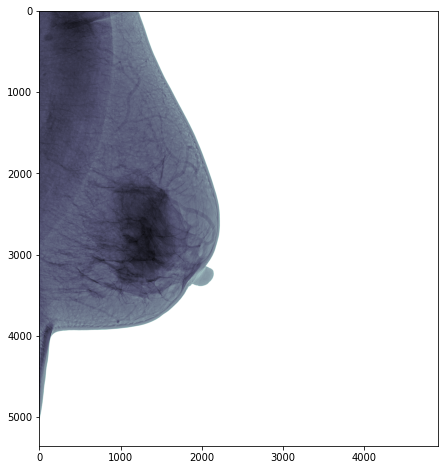

In [8]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

import matplotlib.pyplot as plt

import pydicom
%matplotlib inline
plt.figure(figsize = (10,8))
image = pydicom.dcmread(X[21])
plt.imshow(image.pixel_array,cmap=plt.cm.bone);

In [9]:
#Code by Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

## Function to Display 25 Images
def show_25_images(images):
    """
    Displays a plot of 25 images and their labes for training images
    """
    
    # setup the figure
    plt.figure(figsize = (10,10))
    
    # loop through 25 files to display 25 images
    for i in range(25):
        # Create subplots ( 5 rows , 5 columns)
        ax = plt.subplot(5,5,i+1)
        # display an image
        image = pydicom.dcmread(images[i])
        plt.imshow(image.pixel_array,cmap = plt.cm.bone)
        plt.axis("off")

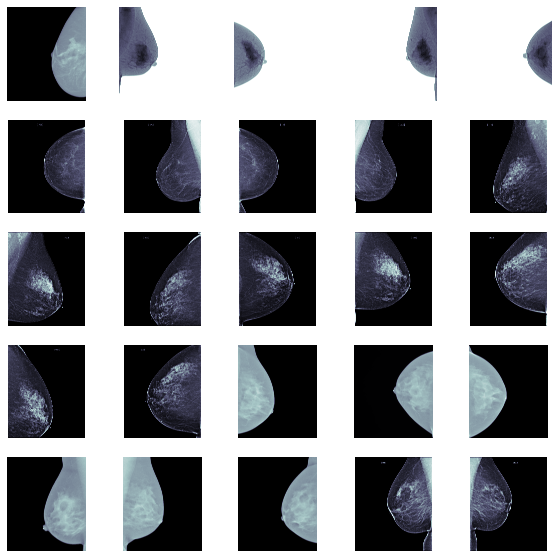

In [10]:
show_25_images(X[20:])

#Code by _lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

In [11]:
#Code by _lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

import glob
import pydicom
import nibabel as nib
from pydicom.pixel_data_handlers.util import apply_voi_lut
import matplotlib.patches as patches

In [12]:
#Code by _lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

DATA_DIR = "../input/rsna-breast-cancer-detection"
TRAIN_DIR = os.path.join(DATA_DIR, "train_images")
#SEGM_DIR = os.path.join(DATA_DIR, "segmentations")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(train_df.shape)
train_df.head()

(54706, 14)


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


#Normal Breast Implants. What We Must Know to Avoid Misinterpretations

Teaching Points

"Nowadays there are many different types of breast implants and some of them with particular landmarks that could lead to misinterpretations by unexperienced radiologists.The authors selected 10 types of implants from different manufacturers commonly used in plastic surgery.The purpose of this exhibit is: To demonstrate the most common types of breast implants, especially some specific landmarks and main anatomical features that could lead to misinterpretations; To demonstrate in detail the microscopic anatomical characteristics of breast implants shell; To correlate the findings of both in vitro and in vivo through different imaging modalities: mammography, ultrasound and MRI."

https://archive.rsna.org/2015/MagneticResonanceImaging.pdf

In [18]:
#Code by _lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

example = "../input/rsna-breast-cancer-detection/train_images/10706/763186195.dcm"
example_ds = pydicom.dcmread(example)
example_ds

Dataset.file_meta -------------------------------
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Digital X-Ray Image Storage - For Presentation
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.840.10009.1.2.3.10706.1.763186195
(0002, 0010) Transfer Syntax UID                 UI: JPEG 2000 Image Compression (Lossless Only)
(0002, 0012) Implementation Class UID            UI: 1.2.840.113654.2.3.1995.2.12.0
(0002, 0013) Implementation Version Name         SH: 'PYDICOM 2.3.0'
-------------------------------------------------
(0008, 0018) SOP Instance UID                    UI: 1.2.840.10009.1.2.3.10706.1.763186195
(0008, 0023) Content Date                        DA: '20221118'
(0008, 0033) Content Time                        TM: '184026.815884'
(0010, 0020) Patient ID                          LO: '10706'
(0020, 000d) Study Instance UID                  UI: 1.2.840.10009.1.2.3.10706
(0020, 000e) Series Instance U

#What is breast implant associated cancer?

"Breast implant associated cancer, which is also known as breast implant associated anaplastic large cell lymphoma (BIA-ALCL), is a rare cancer of the immune system. It is not breast cancer, which forms from cells in the breast, but instead a cancer that grows in the fluid and scar tissue that forms around a breast implant. Less commonly, BIA-ALCL can take the form of a lump in the breast or a lump in the armpit."

"BIA-ALCL has been known to occur as soon as one year after the operation and as late as 37 years after the operation. The average time to diagnosis is within 8 years of the operation."

https://www.tga.gov.au/breast-implant-associated-cancer-bia-alcl-information-consumers

In [19]:
# source: https://www.kaggle.com/code/allunia/rsna-csf-cervical-spine-fracture-eda/notebook
def rescale_img_to_hu(dcm_ds):
    """Rescales the image to Hounsfield unit.
    """
    return dcm_ds.pixel_array * dcm_ds.RescaleSlope + dcm_ds.RescaleIntercept

#Who can get breast implant associated cancer?

"All reported cases of breast implant associated cancer in Australia involve patients who have had a textured implant at some point in their life. Based on current evidence, experts do not think breast implant associated cancer is related to either the contents (saline/silicone) or shape (round/teardrop) of the implant."

"Breast implant associated cancer is rare. The recent review by the TGA has found between one in 2,500 and one in 25,000 people with breast implants are diagnosed with the condition in Australia; based on confirmed cases of BIA-ALCL where only one brand of implant had been used. The risk of developing BIA-ALCL increases with increasing texturing of the implant. Implants which have a smooth surfaced have not been associated with BIA-ALCL. Breast implant associated cancer can occur after either reconstruction or augmentation surgery, with 95% of cases occurring between three and 14 years after the insertion of an implant.'

https://www.tga.gov.au/breast-implant-associated-cancer-bia-alcl-information-consumers

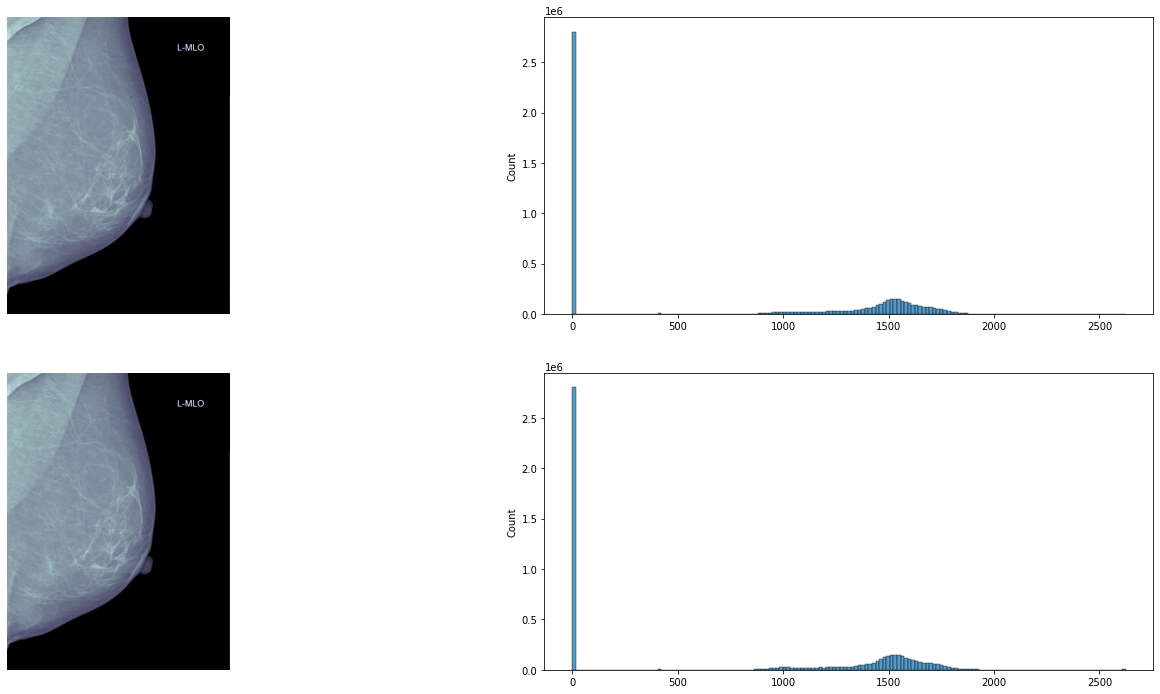

In [21]:
#Code by _lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

# original image
fig, axs = plt.subplots(2, 2, figsize=(24, 12))
axs[0, 0].imshow(example_ds.pixel_array, cmap="bone")
axs[0, 0].axis("off")
sns.histplot(example_ds.pixel_array.flatten(), ax=axs[0, 1])

# rescaled image
rescaled_img = rescale_img_to_hu(example_ds)
axs[1, 0].imshow(rescaled_img, cmap="bone")
axs[1, 0].axis("off")
sns.histplot(rescaled_img.flatten(), ax=axs[1, 1]);

#How is breast implant associated cancer diagnosed?

"If you develop swelling of an implanted breast your doctor will send you for an ultrasound scan to see if this is due to a fluid collection. If fluid is present it will be removed and sent to the laboratory for analysis. Most fluid collections are not due to BIA-ALCL, but the laboratory test will be able to tell for sure."

"If confirmed, your specialist may also order an MRI scan or CT scan to assess the extent of local growth or distant spread of the cancer. Other tests such as a PET scan may be also used to assess spread."

"A mammogram will check for breast cancer, but is not useful for detecting BIA-ALCL."

https://www.tga.gov.au/breast-implant-associated-cancer-bia-alcl-information-consumers

#Since I don't have segmentations, bboxes and slices I'm not able to go further with those codes to make 3D or anything else.

In [27]:
!pip install PyPDF2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.6/220.6 kB 5.0 MB/s eta 0:00:0000:01


#An Integrated Machine Learning Scheme for Predicting Mammographic Anomalies in High-Risk Individuals Using Questionnaire-Based Predictors

Citation: Sun, C.-K.; Tang, Y.-X.; Liu, T.-C.; Lu, C.-J. An Integrated Machine Learning Scheme for Predicting Mammographic Anomalies in High-Risk Individuals Using Questionnaire-Based Predictors.
Int. J. Environ. Res. Public Health 2022, 19, 9756. https://doi.org/10.3390/ ijerph19159756

![](https://www.mdpi.com/ijerph/ijerph-19-09756/article_deploy/html/images/ijerph-19-09756-g002.png)https://www.mdpi.com/1660-4601/19/15/9756

In [28]:
# importing module to read PDF
import PyPDF2
  
# creating a pdf file object
pdfFileObj = open('../input/cusersmarildownloadsijerph1909756pdf/ijerph-19-09756.pdf', 'rb')

In [29]:
# creating a pdf reader object
pdfReader = PyPDF2.PdfFileReader(pdfFileObj)
  
# printing number of pages in pdf file
print(pdfReader.numPages)
  
# creating a page object
pageObj = pdfReader.getPage(7)

17


#Predicting mammographic anomalies in high-risk individuals.

In [30]:
# extracting text from page
print(pageObj.extractText())
  
# closing the pdf file object
#pdfFileObj.close()

Int. J. Environ. Res. Public Health 2022 ,19, 9756 8 of 17
2.3. Proposed Integrated ML Scheme
This study proposes an integrated ML scheme that utilizes the advantages of Lasso
and XGB methods to construct predictive models and identify important predictor variables
for predicting mammographic anomalies in high-risk individuals.
XGB is implemented under the gradient-boosting framework, designed to be highly
efﬁcient, ﬂexible, and portable. It belongs to a broader collection of tools under the umbrella
of the distributed ML community and is a research project started by Chen [ 27]. Logistic
regression is a widely used classic regression algorithm [ 19,28] that focuses on binary
classiﬁcation problems by calculating the natural logarithm of the odds ratio (logit) [ 29].
To obtain a more accurate prediction using shrinkage, Lasso is a regularization technique
used over the logistic regression method, where data values are shrunk toward a central
point as the mean [30].
Figure 3 shows the ﬂ

In [31]:
# creating a page object
pageObj = pdfReader.getPage(8)

# extracting text from page
print(pageObj.extractText())

Int. J. Environ. Res. Public Health 2022 ,19, 9756 9 of 17
Int. J. Environ. Res. Public Health 2022 , 19, x FOR PEER REVIEW 8 of 16 
 
 used [32]. The bootstrapping method is a well-known sampling strategy, which is 
sampling with replacement to decrease th e amount of the majority class [33]. 
 
Figure 3. Proposed integrated ML scheme. 
There are two stages in the modeling of the proposed scheme. In modeling stage I, 
Lasso logistic regression was fitted with all variables (called the full model) to calculate 
the confidence interval (CI) of the performa nce index area under the receiver operating 
characteristic (ROC) curve (AUC) for the me thod. Calculating the CI of the AUC can 
indicate the stability of the model’s perfor mance. Simultaneously , XGB was also fitted 
with all variables in this stage to obtain the variable importance rankings, which were 
used to generate the variable combinations.  
It is important to remember that ML methods can highlight multivariate interaction 

In [32]:
# closing the pdf file object
pdfFileObj.close()

#Factors associated with the risk of positive mammography screening for breast cancer using the proposed integrated ML scheme.

"By analyzing 18 factors possibly associated with the risk of positive mammography screening for breast cancer using the proposed integrated ML scheme, the authors identified: "

younger age,

breast self-examination,

older age at first childbirth,

nulliparity 

"and history of mammography within the preceding 2 years as the top five significant variables for
predicting positive mammography results."

"Their findings suggested a benefit for women with the identified risk factors for timely mammographic screening."

https://pubmed.ncbi.nlm.nih.gov/35955112/

#Conclusion

A good diagnosis and its prognosis is the result of analysing all the "features": history, examination (physical exam), hear the patient and the complimentary exams.(e.g. Mammogram, Breast Ultrasound,MRI...) 

Acknowledgements:

Sumeet Sagar https://www.kaggle.com/code/ssagar012/siim-covid-19-novice-notebook-eda-box-detection

_lev_lipinski https://www.kaggle.com/code/leventelippenszky/rsna-eda-dicom-segmentations-bboxes-3d-plot

Laura Fink https://www.kaggle.com/code/allunia/rsna-csf-cervical-spine-fracture-eda/notebook

PyPDF2 https://pypi.org/project/PyPDF2/

Vijayendra D. https://www.kaggle.com/code/vijayendrad/kaggle-ds-survey-2022/notebook